In [12]:
import sys
# ambiente no anaconda
print(sys.executable)

/home/fabiene/anaconda3/envs/udemy_serie_arima/bin/python


In [13]:
# no linux

# conda env list
# # conda environments:
# #
# base                  *  /home/fabiene/anaconda3
# Maq2                     /home/fabiene/anaconda3/envs/Maq2
# RBA_est                  /home/fabiene/anaconda3/envs/RBA_est
# Robyn                    /home/fabiene/anaconda3/envs/Robyn
# Udemy                    /home/fabiene/anaconda3/envs/Udemy
# YouTube                  /home/fabiene/anaconda3/envs/YouTube
# face-env                 /home/fabiene/anaconda3/envs/face-env
# orange3                  /home/fabiene/anaconda3/envs/orange3
# pycaret-env              /home/fabiene/anaconda3/envs/pycaret-env


#(base) fabiene@~$ conda create --name udemy_serie_arima
# conda activate udemy_serie_arima
# (udemy_serie_arima) fabiene@:~$ 




# Série temporal com Facebook Prophet - previsão de visualizações diárias de páginas web

Prophet => profeta

## Instalação da biblioteca e importação da base de dados

- Visualizações diárias de uma página web da Wikipedia: https://en.wikipedia.org/wiki/Peyton_Manning

Peyton Williams Manning (born March 24, 1976) is an American former professional football quarterback

In [14]:
import pandas as pd

dataset = pd.read_csv('page_wikipedia.csv')
dataset.tail(20)

,date,views
2885,2016-01-01,7.589336
2886,2016-01-02,7.825245
2887,2016-01-03,8.249314
2888,2016-01-04,9.295141
2889,2016-01-05,8.568266
2890,2016-01-06,8.352554
2891,2016-01-07,8.295798
2892,2016-01-08,8.290293
2893,2016-01-09,7.785721
2894,2016-01-10,8.281724


In [15]:
#!pip install fbprophet

# atualizado 
#!pip install prophet

In [16]:
#from fbprophet import Prophet


In [17]:
import prophet

In [29]:
# nove anos de dados completos
dataset_teste = dataset.copy()

In [19]:
dataset_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2905 entries, 0 to 2904
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2905 non-null   object 
 1   views   2905 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.5+ KB


In [20]:
dataset_teste['date'] = pd.to_datetime(dataset_teste['date'])

In [21]:
dataset_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2905 entries, 0 to 2904
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2905 non-null   datetime64[ns]
 1   views   2905 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 45.5 KB


In [23]:
# %m é o mês com dois dígitos, %Y é o ano com quatro dígitos
#dataset_teste['mes-ano'] = dataset_teste['date'].dt.strftime('%m-%Y')

In [24]:
dataset_teste['mes-ano'] = (
    dataset_teste['date'].dt.month.astype(str) + 
    '-' + 
    dataset_teste['date'].dt.year.astype(str)
)

In [25]:
dataset_teste['mes-ano'].unique()

array(['12-2007', '1-2008', '2-2008', '3-2008', '4-2008', '5-2008',
       '6-2008', '7-2008', '8-2008', '9-2008', '10-2008', '11-2008',
       '12-2008', '1-2009', '2-2009', '3-2009', '4-2009', '5-2009',
       '6-2009', '7-2009', '8-2009', '9-2009', '10-2009', '11-2009',
       '12-2009', '1-2010', '2-2010', '3-2010', '4-2010', '5-2010',
       '6-2010', '7-2010', '8-2010', '9-2010', '10-2010', '11-2010',
       '12-2010', '1-2011', '2-2011', '3-2011', '4-2011', '5-2011',
       '6-2011', '7-2011', '8-2011', '9-2011', '10-2011', '11-2011',
       '12-2011', '1-2012', '2-2012', '3-2012', '4-2012', '5-2012',
       '6-2012', '7-2012', '8-2012', '9-2012', '10-2012', '11-2012',
       '12-2012', '1-2013', '2-2013', '3-2013', '4-2013', '5-2013',
       '6-2013', '7-2013', '8-2013', '9-2013', '10-2013', '11-2013',
       '12-2013', '1-2014', '2-2014', '3-2014', '4-2014', '5-2014',
       '6-2014', '7-2014', '8-2014', '9-2014', '10-2014', '11-2014',
       '12-2014', '1-2015', '2-2015', '3-

In [26]:
dataset_teste['ano'] = (
    dataset_teste['date'].dt.year
)

In [27]:
dataset_teste['ano'].unique()

array([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016],
      dtype=int32)

In [28]:
len(dataset_teste['ano'].unique())

10

média, desvio padrão, primeiro quartil (25%), 50% mediana e 75% (terceiro quartil), valores máximos e mínimos

In [30]:
dataset.describe()

,views
count,2905.000000
mean,8.138958
std,0.845957
min,5.262690
25%,7.514800
50%,7.997999
75%,8.580168
max,12.846747


histograma 

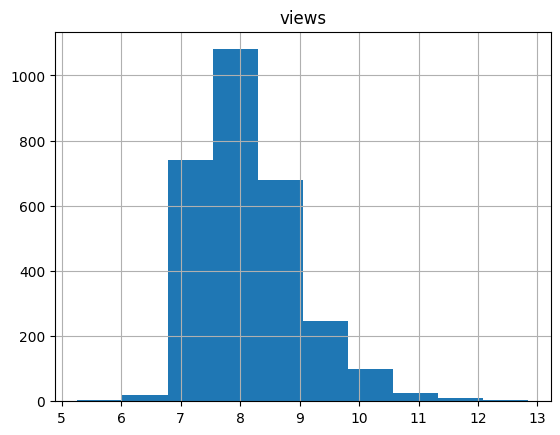

In [32]:
dataset.hist(); # maior frequência entre 7 e 8 visualizações

In [33]:
# padrão aceito para a biblioteca prophet ds data e dados de análise em y 
dataset = dataset[['date', 'views']].rename(columns = {'date': 'ds', 'views': 'y'})
dataset

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


In [34]:
# antes de rdar o programa temos que ordenar as datas
dataset = dataset.sort_values(by = 'ds')
dataset

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871
